# Social media — analysis & production-oriented models

**Data:** `social_media_posts` joined to `donations` on `referral_post_id` → `post_id`.

### Notebook map

| Part | Sections | Focus |
|------|-----------|--------|
| **A — Exploratory** | 1–4, strategy playbook | Lift tables, timing, boost vs organic, correlations |
| **B — Problem & modeling** | Problem definition → §5 | Targets, pipelines, baselines, time-aware CV, metrics |
| **C — Deployment variants** | §6 | Pre-publish (no reach/impressions) vs post-publish |
| **D — Insights & limitations** | Closing | Business takeaways, ROI framing, caveats |

This notebook profiles what drives **referrals and revenue**, **when** to post, **boosted vs organic** performance, and **engagement** vs **fundraising** — then fits **leakage-aware models** and translates results into strategy.


## Problem definition (supervised learning)

We treat social performance as **several related prediction problems** with an explicit **decision time** = `created_at` (when the post is published or scheduled). All models use **chronological** evaluation so future posts never train on past targets.

### Targets and horizons

| Problem | Label | Interpretation |
|---------|--------|----------------|
| **Engagement** | `engagement_rate` | Platform-reported engagement intensity for the post (as stored in exports — treat as *outcome after publish*, not a 7-day window unless your ETL defines one). |
| **Platform donation signal** | `estimated_donation_value_php` | Platform-side estimated fundraising value tied to the post. **Not** the same as cash in CRM. |
| **CRM attribution** | `referral_php` | Sum of **attributed** gift PHP from `donations` via `referral_post_id` (sparse; many zeros). |
| **Conversion (binary)** | `has_referral` | Whether ≥1 CRM-attributed gift exists for the post. |

**Primary operational use cases:**

1. **Pre-publish planner** — predict engagement / proxies using only copy, schedule fields, and planned boost (§6 variant A).
2. **Post-publish estimator** — same targets but includes early `reach` / `impressions` (§6 variant B).

### Features and leakage

- **Global models (§5)** include reach/impressions where present → closer to *post-hoc* explanation than strict pre-publish planning.
- **Lexicon and cadence features** (`caption_*`, `prior_posts_same_platform`, `hours_since_last_same_platform`) use only text and timestamps **available at** `created_at`.
- **CRM targets** (`has_referral`, `referral_php`) do not enter feature columns.

### Success criteria

Models should **beat simple baselines** (train-set mean for regression) on **MAE, RMSE, and R²** (regression) and **F1 + ROC-AUC** (classification), with stability checked via **time-series cross-validation**.


## Data preparation

Loads CSV exports, builds the analysis frame `p`, and sets global reproducibility seeds.


## Data preparation

Loads CSV exports, builds the analysis frame `p`, and sets global reproducibility seeds.


In [55]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("lighthouse_csv_v7")
posts = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"])
donations = pd.read_csv(DATA_DIR / "donations.csv", parse_dates=["donation_date"])


def donation_value_php(row: pd.Series) -> float:
    if row["donation_type"] == "Monetary" and pd.notna(row["amount"]):
        return float(row["amount"])
    if row["donation_type"] == "InKind" and pd.notna(row["estimated_value"]):
        return float(row["estimated_value"])
    return 0.0


donations = donations.copy()
donations["value_php"] = donations.apply(donation_value_php, axis=1)
ref = donations[donations["referral_post_id"].notna()].copy()
ref["referral_post_id"] = ref["referral_post_id"].astype(int)
donations_by_post = ref.groupby("referral_post_id", as_index=False).agg(
    n_referral_gifts=("donation_id", "count"),
    referral_php=("value_php", "sum"),
)
donations_by_post = donations_by_post.rename(columns={"referral_post_id": "post_id"})

p = posts.merge(donations_by_post, on="post_id", how="left")
p["has_referral"] = p["n_referral_gifts"].fillna(0) > 0
p["referral_php"] = p["referral_php"].fillna(0)
p["n_referral_gifts"] = p["n_referral_gifts"].fillna(0)

p["cta_label"] = p["call_to_action_type"].fillna("(no CTA type)").replace("", "(no CTA type)")

print("Posts:", len(p), "| Referral-linked donation rows:", len(ref))
print("Posts with ≥1 attributed gift:", p["has_referral"].sum())
pd.DataFrame(
    {"value": [p["engagement_rate"].mean(), p["donation_referrals"].sum(), p["estimated_donation_value_php"].sum()]},
    index=["Mean engagement_rate (all posts)", "Sum donation_referrals (platform)", "Sum estimated_donation_value_php"],
)


Posts: 812 | Referral-linked donation rows: 77
Posts with ≥1 attributed gift: 62


,value
Mean engagement_rate (all posts),9.898017e-02
Sum donation_referrals (platform),1.039000e+04
Sum estimated_donation_value_php,3.229494e+07


## 1. Post characteristics that drive donations (attributed gifts)

We compare **share of referral PHP** and **mean post-level metrics** by dimension. For fundraising, prioritize categories with **high total `referral_php`** or **lift** vs volume share.

=== platform ===


,posts,referral_php_sum,referral_gifts,mean_engagement,mean_platform_referrals,mean_est_value,share_posts,share_referral_php,lift_php
platform,,,,,,,,,
Facebook,199,14712.76,19.0,0.0939,10.9347,31086.1890,0.2451,0.2718,1.1092
YouTube,71,9113.72,12.0,0.0986,19.9577,59060.7566,0.0874,0.1684,1.9258
TikTok,89,8142.48,13.0,0.0987,19.5506,57424.5720,0.1096,0.1504,1.3726
Instagram,164,7820.45,13.0,0.1061,11.5793,30989.3326,0.2020,0.1445,0.7154
WhatsApp,93,6852.66,9.0,0.0917,23.0968,78438.0968,0.1145,0.1266,1.1055
Twitter,117,4732.12,6.0,0.1043,5.7436,14264.2063,0.1441,0.0874,0.6068
LinkedIn,79,2749.83,5.0,0.0983,4.2785,34921.2928,0.0973,0.0508,0.5222


=== post_type ===


,posts,referral_php_sum,referral_gifts,mean_engagement,mean_platform_referrals,mean_est_value,share_posts,share_referral_php,lift_php
post_type,,,,,,,,,
ImpactStory,203,21646.78,34.0,0.0967,36.3941,116160.6721,0.2500,0.3999,1.5998
FundraisingAppeal,90,13008.63,18.0,0.1082,14.0778,36155.8110,0.1108,0.2403,2.1685
Campaign,156,8521.30,11.0,0.1094,8.9936,28141.2958,0.1921,0.1574,0.8195
EventPromotion,131,4881.52,6.0,0.0940,1.0458,2762.6859,0.1613,0.0902,0.5590
EducationalContent,114,3566.79,5.0,0.0879,0.8421,3183.2318,0.1404,0.0659,0.4694
ThankYou,118,2499.00,3.0,0.0983,0.8390,2927.6119,0.1453,0.0462,0.3177


=== media_type ===


,posts,referral_php_sum,referral_gifts,mean_engagement,mean_platform_referrals,mean_est_value,share_posts,share_referral_php,lift_php
media_type,,,,,,,,,
Video,212,23406.70,29.0,0.0975,14.9245,47762.9959,0.2611,0.4325,1.6564
Photo,227,9787.40,16.0,0.0988,11.7357,34564.6400,0.2796,0.1808,0.6469
Text,154,7821.28,12.0,0.0989,6.9610,25231.2208,0.1897,0.1445,0.7619
Reel,121,7234.94,11.0,0.1001,19.6942,55283.7464,0.1490,0.1337,0.8970
Carousel,98,5873.70,9.0,0.1014,11.2959,38245.6157,0.1207,0.1085,0.8992


=== sentiment_tone ===


,posts,referral_php_sum,referral_gifts,mean_engagement,mean_platform_referrals,mean_est_value,share_posts,share_referral_php,lift_php
sentiment_tone,,,,,,,,,
Hopeful,149,13318.45,16.0,0.0981,9.8658,30609.3801,0.1835,0.2461,1.3410
Informative,162,9946.63,13.0,0.0605,8.0432,19974.0366,0.1995,0.1838,0.9211
Celebratory,113,9604.46,14.0,0.1317,17.9115,56844.8824,0.1392,0.1775,1.2751
Emotional,138,8660.06,12.0,0.1235,18.1087,56921.5748,0.1700,0.1600,0.9415
Urgent,120,7850.70,15.0,0.1071,17.5500,60336.6848,0.1478,0.1451,0.9815
Grateful,130,4743.72,7.0,0.0859,7.6000,22917.6715,0.1601,0.0876,0.5474


=== cta_label ===


,posts,referral_php_sum,referral_gifts,mean_engagement,mean_platform_referrals,mean_est_value,share_posts,share_referral_php,lift_php
cta_label,,,,,,,,,
(no CTA type),319,21209.41,28.0,0.0861,14.2915,45173.3588,0.3929,0.3919,0.9975
LearnMore,131,10737.57,15.0,0.1021,15.0000,43163.3277,0.1613,0.1984,1.2297
DonateNow,123,9592.99,17.0,0.1063,7.3089,24867.9847,0.1515,0.1772,1.1701
SignUp,118,8320.40,11.0,0.1098,12.4153,36312.5206,0.1453,0.1537,1.0579
ShareStory,121,4263.65,6.0,0.1115,12.4132,40385.1497,0.1490,0.0788,0.5286


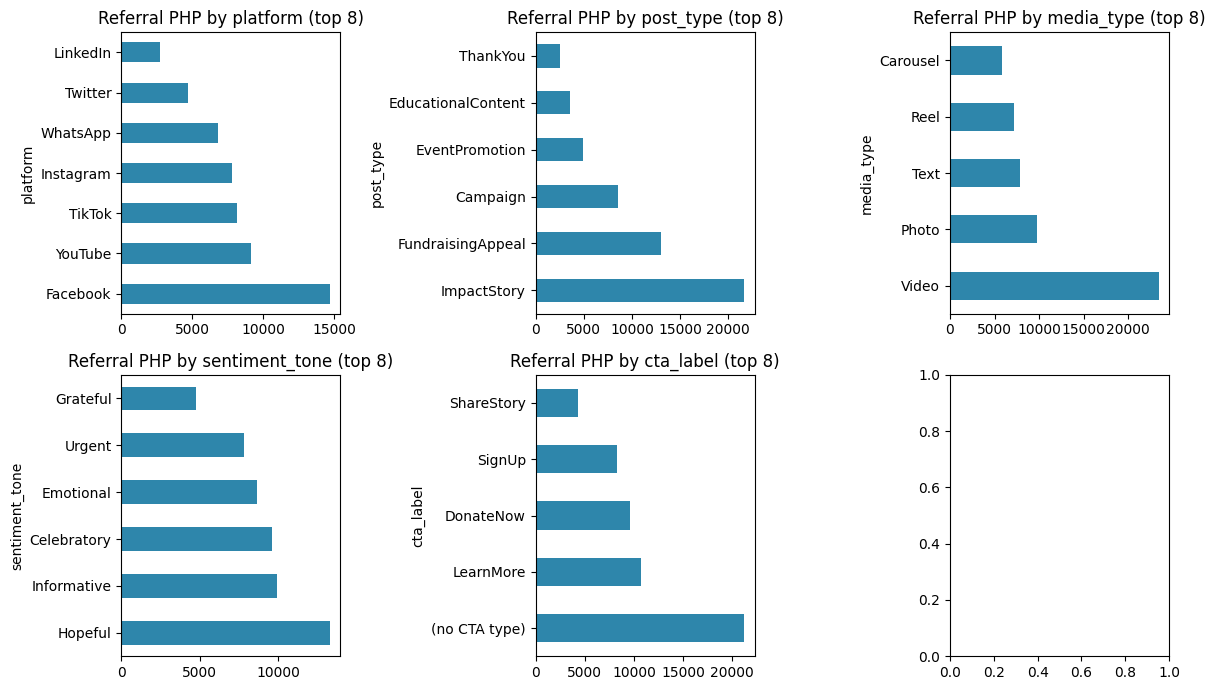

In [56]:
def lift_table(df: pd.DataFrame, col: str, value_col: str = "referral_php"):
    tot = df[value_col].sum()
    g = df.groupby(col, dropna=False).agg(
        posts=("post_id", "count"),
        referral_php_sum=(value_col, "sum"),
        referral_gifts=("n_referral_gifts", "sum"),
        mean_engagement=("engagement_rate", "mean"),
        mean_platform_referrals=("donation_referrals", "mean"),
        mean_est_value=("estimated_donation_value_php", "mean"),
    )
    g["share_posts"] = g["posts"] / len(df)
    g["share_referral_php"] = g["referral_php_sum"] / tot if tot > 0 else 0
    g["lift_php"] = g["share_referral_php"] / g["share_posts"].replace(0, np.nan)
    return g.sort_values("referral_php_sum", ascending=False)


dims = [
    "platform",
    "post_type",
    "media_type",
    "sentiment_tone",
    "cta_label",
]
for col in dims:
    print("===", col, "===")
    display(lift_table(p, col).round(4))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, dims):
    t = lift_table(p, col)
    top = t.head(8)
    top["referral_php_sum"].plot(kind="barh", ax=ax, color="#2E86AB")
    ax.set_title(f"Referral PHP by {col} (top 8)")
plt.tight_layout()
plt.show()

## 2. Timing — best `day_of_week` and `post_hour`

We use **mean** post-level metrics (engagement, platform referrals, est. value) by slot. Interpret with caution: confounded by content mix.

By day of week:


,n,engagement,don_referrals,est_don,referral_php
day_of_week,,,,,
Monday,108,0.0975,13.2963,41300.2994,11409.30
Tuesday,136,0.0942,16.2059,57084.5005,13972.28
Wednesday,110,0.0942,11.1909,33904.4639,6111.67
Thursday,113,0.0941,10.1681,23247.5563,4547.29
Friday,127,0.1046,13.0866,40130.9074,1959.10
Saturday,116,0.1057,12.0259,39406.9691,7341.85
Sunday,102,0.1029,12.8725,39673.6973,8782.53


Hours with at least 15 posts (stable averages):


,n,engagement,don_referrals,est_don,referral_php
post_hour,,,,,
19,68,0.1472,21.2794,69080.6260,9773.06
20,46,0.1412,12.6739,35878.5198,7072.25
11,43,0.1317,16.1628,52243.8993,3851.78
18,40,0.1273,21.5750,41581.6497,6645.16
10,47,0.1230,31.7447,111170.0704,3184.71
21,40,0.1182,13.2250,41700.8015,1887.11
13,37,0.1174,16.3243,45996.0246,3360.75
9,50,0.1151,13.8400,55678.0242,3844.30
12,36,0.1062,13.8611,51561.4808,4269.02


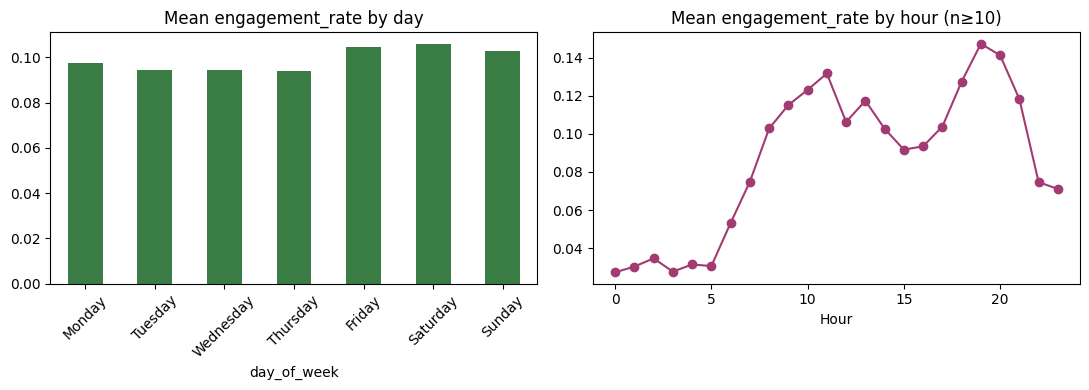

/var/folders/mf/tkf4xfg90c39qhz9fr8msz7w0000gn/T/ipykernel_5518/2953790806.py:50: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = p.pivot_table(


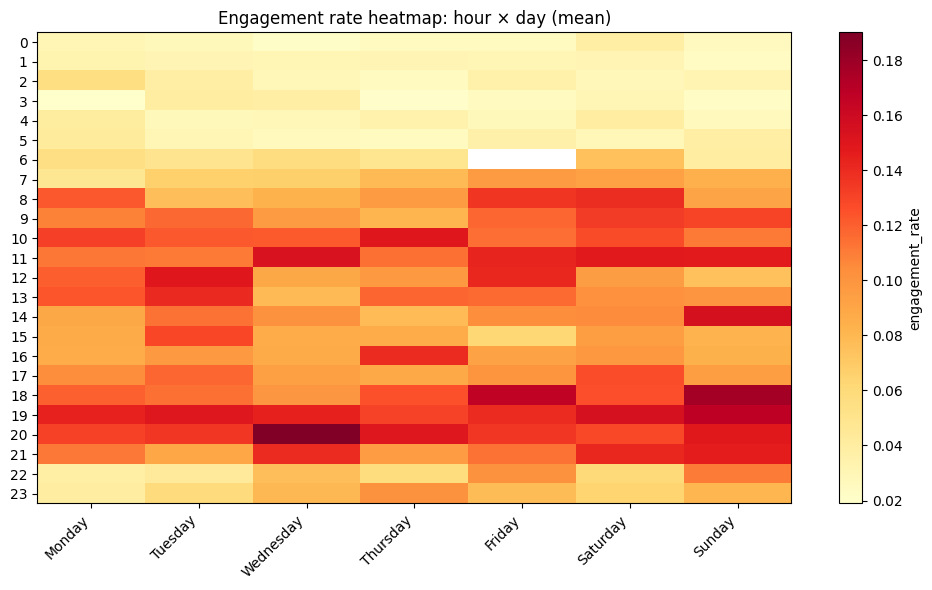

In [57]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
p["day_of_week"] = pd.Categorical(p["day_of_week"], categories=day_order, ordered=True)

by_day = (
    p.groupby("day_of_week", observed=False)
    .agg(
        n=("post_id", "count"),
        engagement=("engagement_rate", "mean"),
        don_referrals=("donation_referrals", "mean"),
        est_don=("estimated_donation_value_php", "mean"),
        referral_php=("referral_php", "sum"),
    )
    .reindex(day_order)
)
print("By day of week:")
display(by_day.round(4))

by_hour = (
    p.groupby("post_hour")
    .agg(
        n=("post_id", "count"),
        engagement=("engagement_rate", "mean"),
        don_referrals=("donation_referrals", "mean"),
        est_don=("estimated_donation_value_php", "mean"),
        referral_php=("referral_php", "sum"),
    )
    .sort_values("post_hour")
)
print("Hours with at least 15 posts (stable averages):")
display(by_hour[by_hour["n"] >= 15].sort_values("engagement", ascending=False).head(12).round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_day["engagement"].plot(kind="bar", ax=axes[0], color="#3A7D44")
axes[0].set_title("Mean engagement_rate by day")
axes[0].tick_params(axis="x", rotation=45)
by_hour[by_hour["n"] >= 10]["engagement"].plot(ax=axes[1], color="#A23B72", marker="o")
axes[1].set_title("Mean engagement_rate by hour (n≥10)")
axes[1].set_xlabel("Hour")
plt.tight_layout()
plt.show()

heat = p.pivot_table(
    values="engagement_rate",
    index="post_hour",
    columns="day_of_week",
    aggfunc="mean",
)
heat = heat.reindex(columns=day_order)
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title("Engagement rate heatmap: hour × day (mean)")
plt.colorbar(im, ax=ax, label="engagement_rate")
plt.tight_layout()
plt.show()

## 3. Boosted vs organic (`is_boosted`)

Compare **reach**, **engagement**, **platform-reported referrals**, and **estimated donation value** — boosted posts often have different creative and budget.

,posts,mean_reach,mean_impressions,mean_engagement,sum_platform_referrals,mean_platform_referrals,sum_est_don,mean_est_don,attributed_referral_php,mean_budget
is_boosted,,,,,,,,,,
False,685,2827.28,4395.13,0.10,7631,11.14,23329357.12,34057.46,46350.57,NaN
True,127,8302.43,12749.87,0.09,2759,21.72,8965582.94,70595.14,7773.45,2430.14


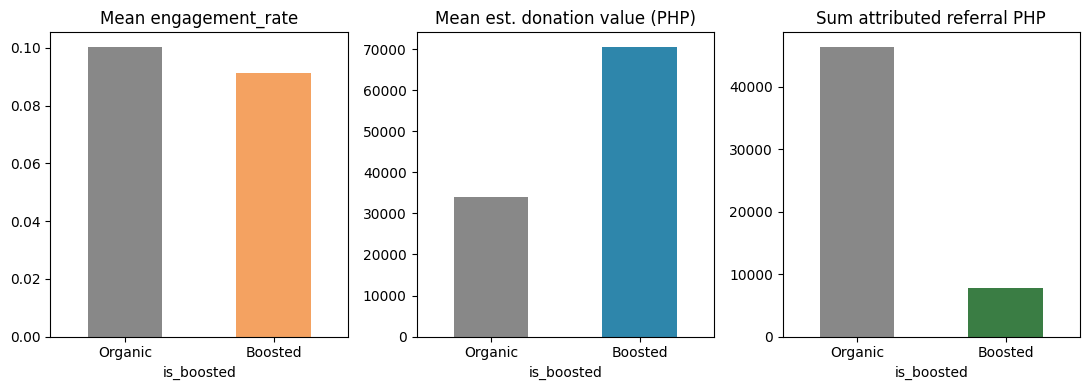

In [58]:
boost = p.groupby("is_boosted").agg(
    posts=("post_id", "count"),
    mean_reach=("reach", "mean"),
    mean_impressions=("impressions", "mean"),
    mean_engagement=("engagement_rate", "mean"),
    sum_platform_referrals=("donation_referrals", "sum"),
    mean_platform_referrals=("donation_referrals", "mean"),
    sum_est_don=("estimated_donation_value_php", "sum"),
    mean_est_don=("estimated_donation_value_php", "mean"),
    attributed_referral_php=("referral_php", "sum"),
    mean_budget=("boost_budget_php", "mean"),
)
display(boost.round(2))

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
boost["mean_engagement"].plot(kind="bar", ax=axes[0], color=["#888", "#F4A261"])
axes[0].set_title("Mean engagement_rate")
boost["mean_est_don"].plot(kind="bar", ax=axes[1], color=["#888", "#2E86AB"])
axes[1].set_title("Mean est. donation value (PHP)")
boost["attributed_referral_php"].plot(kind="bar", ax=axes[2], color=["#888", "#3A7D44"])
axes[2].set_title("Sum attributed referral PHP")
for ax in axes:
    ax.set_xticklabels(["Organic", "Boosted"], rotation=0)
plt.tight_layout()
plt.show()

## 4. Patterns that maximize engagement, referrals, and estimated value

We rank **top decile** of posts on each KPI and show **over-represented** `post_type` / `platform` vs baseline.

In [59]:
def top_decile_profile(df: pd.DataFrame, kpi: str, label: str):
    q = df[kpi].quantile(0.9)
    top = df[df[kpi] >= q]
    base_pt = df["post_type"].value_counts(normalize=True)
    top_pt = top["post_type"].value_counts(normalize=True)
    lift_pt = (top_pt / base_pt.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
    lift_pt = lift_pt.sort_values(ascending=False).head(8)
    base_pl = df["platform"].value_counts(normalize=True)
    top_pl = top["platform"].value_counts(normalize=True)
    lift_pl = (top_pl / base_pl.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
    lift_pl = lift_pl.sort_values(ascending=False).head(8)
    print(f"--- Top decile on {label} (threshold {kpi} >= {q:.4f}) — n={len(top)} ---")
    print("Post type lift:")
    display(lift_pt.round(2).to_frame("lift_vs_share"))
    print("Platform lift:")
    display(lift_pl.round(2).to_frame("lift_vs_share"))


top_decile_profile(p, "engagement_rate", "engagement_rate")
top_decile_profile(p, "donation_referrals", "donation_referrals")
top_decile_profile(p, "estimated_donation_value_php", "estimated_donation_value_php")

corr = p[
    [
        "engagement_rate",
        "donation_referrals",
        "estimated_donation_value_php",
        "referral_php",
        "reach",
        "num_hashtags",
        "caption_length",
    ]
].corr(numeric_only=True)
print("Correlation matrix (KPIs vs scale):")
display(corr.round(3))

--- Top decile on engagement_rate (threshold engagement_rate >= 0.1778) — n=82 ---
Post type lift:


,lift_vs_share
post_type,
FundraisingAppeal,1.32
Campaign,1.27
EventPromotion,1.21
ThankYou,1.17
ImpactStory,0.68
EducationalContent,0.52


Platform lift:


,lift_vs_share
platform,
TikTok,1.45
Instagram,1.33
LinkedIn,1.13
YouTube,1.12
WhatsApp,0.85
Twitter,0.85
Facebook,0.60


--- Top decile on donation_referrals (threshold donation_referrals >= 38.0000) — n=83 ---
Post type lift:


...

,lift_vs_share
post_type,
ImpactStory,3.12
FundraisingAppeal,0.99
Campaign,0.57


Platform lift:


,lift_vs_share
platform,
WhatsApp,2.02
YouTube,1.81
TikTok,1.00
LinkedIn,0.88
Facebook,0.85
Instagram,0.85
Twitter,0.25


Correlation matrix (KPIs vs scale):


,engagement_rate,donation_referrals,estimated_donation_value_php,referral_php,reach,num_hashtags,caption_length
engagement_rate,1.000,0.267,0.226,0.106,0.241,-0.017,0.016
donation_referrals,0.267,1.000,0.892,0.109,0.485,-0.027,0.138
estimated_donation_value_php,0.226,0.892,1.000,0.075,0.398,-0.041,0.119
referral_php,0.106,0.109,0.075,1.000,0.112,0.043,0.049
reach,0.241,0.485,0.398,0.112,1.000,0.212,0.081
num_hashtags,-0.017,-0.027,-0.041,0.043,0.212,1.000,0.212
caption_length,0.016,0.138,0.119,0.049,0.081,0.212,1.000


---

## Growth strategy (nonprofit + growth)

- **Double down on formats that win both *share of attributed PHP* and *lift* in section 1** — especially `post_type` / `platform` combos where you punch above your post-count weight.
- **Separate goals:** high **engagement_rate** does not always equal **donations**; allocate a **fundraising** track (clear CTA, urgency, impact story) vs a **community** track (education, trust-building) and measure each separately.
- **Timing:** use section 2 slots to **schedule** tests; run A/Bs holding `post_type` constant so day/hour effects are real.
- **Boosts:** treat paid as **amplification of proven organic winners** — boost posts that already show referral or strong est. value, not cold experiments (unless testing audiences).
- **Attribution hygiene:** keep `donation_referrals` / CRM linkages consistent so you can learn which posts actually fund programs, not only platform estimates.

---

## Optimal posting playbook (90-day)

| Week | Focus | Action |
|------|--------|--------|
| 1–2 | **Baseline** | Export top 20% posts by `referral_php` + `engagement_rate`; tag creative pattern (CTA, story, media). |
| 3–4 | **Timing** | Post 50% of fundraising content in **best hours** from your heatmap; keep content identical for comparability. |
| 5–6 | **Format** | Run 2–3 **ImpactStory** / **FundraisingAppeal** variants per platform; standardize CTA (`DonateNow` vs `LearnMore`). |
| 7–8 | **Boost** | Put **10–20% of boost budget** behind top organic referral posts; compare CPA vs cold boost. |
| 9–12 | **Scale** | Weekly cadence: 2× story/education, 1× direct ask, 1× thank-you/progress; monthly review lift tables. |

---

## What **NOT** to do (anti-patterns)

- **Do not** optimize only **engagement** — vanity metrics can crowd out **donation** and **referral** KPIs.
- **Do not** boost **every** post — dilutes learning and burns budget; boost **after** organic proof.
- **Do not** ignore **CTA** and **sentiment** — missing or vague CTAs and mismatched tone reduce conversion on asks.
- **Do not** post **high-frequency** low-value updates without a **content calendar** tied to campaigns — creates noise and hides attribution.
- **Do not** compare platforms **without normalizing** for audience size and organic reach — use **reach-weighted** or **per-follower** metrics when possible.
- **Do not** treat **estimated_donation_value_php** as cash — reconcile with **CRM `referral_php`** to avoid overconfidence.

---

**Growth-hacker mindset:** ship small experiments, read **lift** not just averages, and **instrument** every ask with UTM + `referral_post_id` so next quarter’s playbook is smarter than this one.

## 5. Modeling — TF-IDF + metadata pipelines

End-to-end **`sklearn.pipeline.Pipeline`** with **`ColumnTransformer`**:
- **TF-IDF** (caption + hashtags) with the same tokenizer as before.
- Numeric + categorical metadata (including **lexicon** and **cadence** features from `prepare_training_frame`).
- **`RandomForestRegressor`** / **`RandomForestClassifier`**.
- **Chronological** holdout + **`TimeSeriesSplit`** CV vs **mean baselines**.
- Regression targets: `engagement_rate`, `estimated_donation_value_php`, **`referral_php`**. Classification: **`has_referral`**.


In [60]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import re

import numpy as np

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


# Align with notebook-level seed (set in Data preparation cell).
RANDOM_STATE = globals().get("RANDOM_STATE", 42)


@dataclass(frozen=True)
class ModelConfig:
    """Configuration for TF-IDF + metadata models."""

    tfidf_max_caption: int = 4000
    tfidf_max_hashtags: int = 2000
    tfidf_min_df: int = 2
    tfidf_max_df: float = 0.98
    n_estimators: int = 400
    random_state: int = RANDOM_STATE


_LEX_DONATE = (
    "donate",
    "donation",
    "give",
    "giving",
    "support",
    "help",
    "fund",
    "fundrais",
    "appeal",
    "contribute",
    "pledge",
    "sponsor",
)
_LEX_URGENT = (
    "urgent",
    "today",
    "now",
    "deadline",
    "last chance",
    "hurry",
    "limited",
    "match",
    "double",
    "only",
)
_LEX_GRATITUDE = (
    "thank",
    "thanks",
    "grateful",
    "appreciate",
    "bless",
    "community",
)
_LEX_EMOTION = (
    "love",
    "hope",
    "together",
    "care",
    "family",
    "children",
    "impact",
    "transform",
    "heal",
    "recover",
)
_LEX_POS = ("hope", "love", "thank", "grateful", "together", "celebrate", "joy", "proud")
_LEX_NEG = ("crisis", "urgent", "struggle", "need", "emergency", "help", "suffer")


def _lex_count(text: str, words: tuple[str, ...]) -> int:
    t = "" if pd.isna(text) else str(text).lower()
    return sum(len(re.findall(rf"\b{re.escape(w)}\b", t)) for w in words)


def normalize_hashtags(raw: str) -> str:
    """Normalize hashtag text into a tokenizer-friendly space-separated string."""
    text = "" if pd.isna(raw) else str(raw)
    text = re.sub(r"[^\#\w\s]", " ", text)
    text = text.replace(",", " ").replace(";", " ")
    return re.sub(r"\s+", " ", text).strip().lower()


def regex_tokenize(text: str) -> List[str]:
    """Word / hashtag tokenizer for TF-IDF `analyzer`."""
    text = "" if pd.isna(text) else str(text).lower()
    return re.findall(r"\#?[a-z0-9_]{2,}", text)


def _to_text_series(df_col: pd.DataFrame) -> pd.Series:
    return df_col.iloc[:, 0].fillna("").astype(str)


def prepare_training_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Modeling frame: bool flags, lexicon/sentiment proxies, leakage-safe cadence features."""
    work = df.copy()

    for col in ["caption", "hashtags"]:
        work[col] = work[col].fillna("").astype(str)

    bool_cols = ["is_boosted", "has_call_to_action", "features_resident_story"]
    for col in bool_cols:
        work[f"{col}_num"] = work[col].fillna(False).astype(int)

    cap = work["caption"]
    work["lex_donate_hits"] = cap.map(lambda s: _lex_count(s, _LEX_DONATE))
    work["lex_urgent_hits"] = cap.map(lambda s: _lex_count(s, _LEX_URGENT))
    work["lex_gratitude_hits"] = cap.map(lambda s: _lex_count(s, _LEX_GRATITUDE))
    work["lex_emotion_hits"] = cap.map(lambda s: _lex_count(s, _LEX_EMOTION))
    pos = cap.map(lambda s: _lex_count(s, _LEX_POS))
    neg = cap.map(lambda s: _lex_count(s, _LEX_NEG))
    work["lex_sentiment_net"] = (pos - neg).astype(float)

    # Cadence: per platform, ordered by time (no future rows used).
    work = work.sort_values(["platform", "created_at"]).reset_index(drop=True)
    work["prior_posts_same_platform"] = work.groupby("platform").cumcount()
    work["hours_since_last_same_platform"] = (
        work.groupby("platform")["created_at"].diff().dt.total_seconds() / 3600.0
    ).fillna(-1.0)
    work = work.sort_values("created_at").reset_index(drop=True)

    return work


def make_regression_pipeline(
    config: ModelConfig,
    numeric_features: List[str],
    categorical_features: List[str],
) -> Pipeline:
    """TF-IDF on caption/hashtags + numeric/categorical metadata + RandomForest regressor."""
    caption_pipe = Pipeline(
        steps=[
            ("to_series", FunctionTransformer(_to_text_series, validate=False)),
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer=regex_tokenize,
                    max_features=config.tfidf_max_caption,
                    min_df=config.tfidf_min_df,
                    max_df=config.tfidf_max_df,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
            ),
        ]
    )

    hashtag_pipe = Pipeline(
        steps=[
            (
                "normalize",
                FunctionTransformer(
                    lambda col: _to_text_series(col).map(normalize_hashtags), validate=False
                ),
            ),
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer=regex_tokenize,
                    max_features=config.tfidf_max_hashtags,
                    min_df=1,
                    max_df=config.tfidf_max_df,
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                ),
            ),
        ]
    )

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler(with_mean=False)),
        ]
    )

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("caption_text", caption_pipe, ["caption"]),
            ("hashtags_text", hashtag_pipe, ["hashtags"]),
            ("numeric", numeric_pipe, numeric_features),
            ("categorical", categorical_pipe, categorical_features),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=config.n_estimators,
        random_state=config.random_state,
        n_jobs=-1,
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )


def make_classification_pipeline(
    config: ModelConfig,
    numeric_features: List[str],
    categorical_features: List[str],
) -> Pipeline:
    """Same preprocessing as regression; RandomForest classifier for sparse positive class."""
    reg_pipe = make_regression_pipeline(config, numeric_features, categorical_features)
    prep = reg_pipe.named_steps["preprocess"]
    clf = RandomForestClassifier(
        n_estimators=config.n_estimators,
        random_state=config.random_state,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    return Pipeline([("preprocess", prep), ("model", clf)])


def time_split(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    train_frac: float = 0.8,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Chronological train/test split (future never predicts past)."""
    data = df.sort_values("created_at").reset_index(drop=True)
    split_idx = int(len(data) * train_frac)

    train = data.iloc[:split_idx]
    test = data.iloc[split_idx:]

    x_train = train[feature_cols]
    y_train = train[target_col]
    x_test = test[feature_cols]
    y_test = test[target_col]

    return x_train, x_test, y_train, y_test


def evaluate_regression(y_true: pd.Series, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def baseline_mean_predictions(y_train: pd.Series, y_test: pd.Series) -> np.ndarray:
    m = float(y_train.mean())
    return np.full(shape=len(y_test), fill_value=m, dtype=float)


def regression_time_series_cv(
    pipeline_template: Pipeline,
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    n_splits: int = 5,
) -> pd.DataFrame:
    """Expanding-window CV; each fold trains on the past, tests on the next slice."""
    data = df[df[target_col].notna()].sort_values("created_at").reset_index(drop=True)
    X = data[feature_cols]
    y = data[target_col]
    tss = TimeSeriesSplit(n_splits=n_splits)
    rows: List[Dict[str, float]] = []
    fold = 0
    for train_idx, test_idx in tss.split(X):
        fold += 1
        if len(test_idx) < 5:
            continue
        est = clone(pipeline_template)
        est.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = est.predict(X.iloc[test_idx])
        base = baseline_mean_predictions(y.iloc[train_idx], y.iloc[test_idx])
        rows.append(
            {
                "fold": fold,
                "test_n": len(test_idx),
                **{f"model_{k}": v for k, v in evaluate_regression(y.iloc[test_idx], pred).items()},
                **{f"baseline_{k}": v for k, v in evaluate_regression(y.iloc[test_idx], base).items()},
            }
        )
    return pd.DataFrame(rows)


def evaluate_classification(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_hat = (y_prob >= 0.5).astype(int)
    out: Dict[str, float] = {
        "f1": float(f1_score(y_true, y_hat, zero_division=0)),
    }
    if len(np.unique(y_true)) > 1:
        out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    else:
        out["roc_auc"] = float("nan")
    return out


model_df = prepare_training_frame(p)
print("Modeling rows:", len(model_df))


Modeling rows: 812


In [61]:
# --- Feature groups (§5 full model: includes post-publish signals) ---
EXTRA_NUMERIC = [
    "lex_donate_hits",
    "lex_urgent_hits",
    "lex_gratitude_hits",
    "lex_emotion_hits",
    "lex_sentiment_net",
    "prior_posts_same_platform",
    "hours_since_last_same_platform",
]

FEATURE_COLUMNS = [
    "caption",
    "hashtags",
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "impressions",
    "reach",
    "follower_count_at_post",
    "boost_budget_php",
    "is_boosted_num",
    "has_call_to_action_num",
    "features_resident_story_num",
    *EXTRA_NUMERIC,
    "platform",
    "post_type",
    "media_type",
    "day_of_week",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
]

TARGETS_REG = ["engagement_rate", "estimated_donation_value_php", "referral_php"]
config = ModelConfig()

NUMERIC_FEATURES_FULL = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "impressions",
    "reach",
    "follower_count_at_post",
    "boost_budget_php",
    "is_boosted_num",
    "has_call_to_action_num",
    "features_resident_story_num",
    *EXTRA_NUMERIC,
]
CATEGORICAL_FEATURES = [
    "platform",
    "post_type",
    "media_type",
    "day_of_week",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
]

results: List[Dict[str, float]] = []
baseline_rows: List[Dict[str, float]] = []
fitted_models: Dict[str, Pipeline] = {}
cv_summaries: Dict[str, pd.DataFrame] = {}

for target in TARGETS_REG:
    filtered = model_df[model_df[target].notna()].copy()

    x_train, x_test, y_train, y_test = time_split(
        filtered,
        feature_cols=FEATURE_COLUMNS,
        target_col=target,
        train_frac=0.8,
    )

    reg = make_regression_pipeline(
        config,
        numeric_features=NUMERIC_FEATURES_FULL,
        categorical_features=CATEGORICAL_FEATURES,
    )
    reg.fit(x_train, y_train)

    preds = reg.predict(x_test)
    base_pred = baseline_mean_predictions(y_train, y_test)

    metrics = evaluate_regression(y_test, preds)
    metrics.update({"target": target, "train_rows": len(x_train), "test_rows": len(x_test)})
    results.append(metrics)

    b = evaluate_regression(y_test, base_pred)
    b.update({"target": target})
    baseline_rows.append(b)

    fitted_models[target] = reg

    tpl = make_regression_pipeline(
        config,
        numeric_features=NUMERIC_FEATURES_FULL,
        categorical_features=CATEGORICAL_FEATURES,
    )
    cv_df = regression_time_series_cv(tpl, filtered, FEATURE_COLUMNS, target, n_splits=5)
    cv_summaries[target] = cv_df

results_df = pd.DataFrame(results).set_index("target")
baseline_df = pd.DataFrame(baseline_rows).set_index("target")

print("Regression vs train-set mean baseline (chronological holdout, MAE / RMSE / R²):")
display(
    pd.concat(
        [results_df.add_prefix("model_"), baseline_df.add_prefix("baseline_")],
        axis=1,
    ).round(4)
)

print("TimeSeriesSplit CV (each fold: model vs baseline MAE):")
for t in TARGETS_REG:
    cdf = cv_summaries[t]
    if cdf.empty:
        print(f"  {t}: insufficient fold sizes")
        continue
    print(f"  {t}: mean test_n={cdf['test_n'].mean():.0f} | model MAE mean={cdf['model_mae'].mean():.4f} | baseline MAE mean={cdf['baseline_mae'].mean():.4f}")
    display(cdf.round(4))


/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is ca

Regression vs train-set mean baseline (chronological holdout, MAE / RMSE / R²):


,model_mae,model_rmse,model_r2,model_train_rows,model_test_rows,baseline_mae,baseline_rmse,baseline_r2
target,,,,,,,,
engagement_rate,0.0265,0.0339,0.6068,649,163,0.0444,0.0541,-0.0021
estimated_donation_value_php,33588.6348,72437.8319,0.3594,649,163,53440.4693,90633.8705,-0.0029
referral_php,168.9818,411.4336,0.0315,649,163,152.5991,420.8742,-0.0135


TimeSeriesSplit CV (each fold: model vs baseline MAE):
  engagement_rate: mean test_n=135 | model MAE mean=0.0280 | baseline MAE mean=0.0456


,fold,test_n,model_mae,model_rmse,model_r2,baseline_mae,baseline_rmse,baseline_r2
0,1,135,0.0324,0.0453,0.3789,0.0474,0.0575,-0.0021
1,2,135,0.0251,0.0334,0.5558,0.0413,0.0503,-0.0087
2,3,135,0.0275,0.0362,0.5820,0.0445,0.0562,-0.0040
3,4,135,0.0289,0.0372,0.6245,0.0506,0.0610,-0.0081
4,5,135,0.0262,0.0338,0.5908,0.0440,0.0529,-0.0016


  estimated_donation_value_php: mean test_n=135 | model MAE mean=38936.5922 | baseline MAE mean=51396.5794


,fold,test_n,model_mae,model_rmse,model_r2,baseline_mae,baseline_rmse,baseline_r2
0,1,135,42785.3829,82499.7452,-0.7275,40729.6724,63147.2000,-0.0121
1,2,135,37166.0367,68093.6078,-0.1140,42593.1712,64561.9374,-0.0014
2,3,135,56199.0970,220315.5178,0.1975,76082.6561,248159.0308,-0.0182
3,4,135,26676.7178,53757.4376,-0.1356,41551.4819,53340.8491,-0.1181
4,5,135,31855.7267,74032.8987,0.3953,56025.9157,95481.0009,-0.0058


  referral_php: mean test_n=135 | model MAE mean=123.5760 | baseline MAE mean=115.7783


,fold,test_n,model_mae,model_rmse,model_r2,baseline_mae,baseline_rmse,baseline_r2
0,1,135,115.8509,351.9375,-0.2298,100.2225,317.3596,-0.0000
1,2,135,79.2705,196.6786,-0.4350,81.5557,165.2393,-0.0129
2,3,135,110.3978,284.3311,-0.1252,111.8698,269.4586,-0.0106
3,4,135,125.9943,413.2043,0.0136,144.0038,418.6286,-0.0124
4,5,135,186.3666,362.9193,-0.0198,141.2396,360.3047,-0.0051


In [62]:
# --- Permutation importance (test holdout): engagement model ---
_perm_target = "engagement_rate"
_perm_filtered = model_df[model_df[_perm_target].notna()].copy()
_px_train, _px_test, _py_train, _py_test = time_split(
    _perm_filtered,
    feature_cols=FEATURE_COLUMNS,
    target_col=_perm_target,
    train_frac=0.8,
)
_perm_pipe = fitted_models[_perm_target]
_perm_result = permutation_importance(
    _perm_pipe,
    _px_test,
    _py_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
try:
    _perm_names = _perm_pipe.named_steps["preprocess"].get_feature_names_out()
except Exception:
    _perm_names = FEATURE_COLUMNS
_perm_imp = pd.Series(_perm_result.importances_mean, index=_perm_names).sort_values(ascending=False)
print(f"Top 25 permutation importances (target={_perm_target}):")
display(_perm_imp.head(25).round(5).to_frame("mean_decrease_mae"))

# --- Strategy bridge: interpretable metadata columns on the same split ---
meta_cols = [c for c in NUMERIC_FEATURES_FULL + CATEGORICAL_FEATURES if c in _px_test.columns]
print("Holdout correlation with engagement_rate (metadata only, descriptive):")
corr_rows = []
for col in meta_cols:
    try:
        corr_val = pd.to_numeric(_px_test[col], errors='coerce').corr(_py_test)
        corr_rows.append({"feature": col, "corr": corr_val})
    except Exception:
        pass
corr_df = pd.DataFrame(corr_rows).dropna().sort_values("corr", key=abs, ascending=False).round(3)
display(corr_df)

Top 25 permutation importances (target=engagement_rate):


,mean_decrease_mae
post_hour,0.83258
sentiment_tone,0.37081
has_call_to_action_num,0.04974
platform,0.01466
call_to_action_type,0.01458
follower_count_at_post,0.00726
reach,0.00710
caption,0.00654
media_type,0.00573
impressions,0.00193


Holdout correlation with engagement_rate (metadata only, descriptive):


,feature,corr
0,post_hour,0.395
5,reach,0.214
9,has_call_to_action_num,0.213
4,impressions,0.209
6,follower_count_at_post,-0.161
16,prior_posts_same_platform,-0.137
7,boost_budget_php,0.113
8,is_boosted_num,-0.091
17,hours_since_last_same_platform,0.073
1,num_hashtags,-0.064


In [63]:
# --- Classification: CRM-attributed conversion (has_referral) ---
CLS_TARGET = "has_referral"
cls_filtered = model_df.copy()

cx_train, cx_test, cy_train, cy_test = time_split(
    cls_filtered,
    feature_cols=FEATURE_COLUMNS,
    target_col=CLS_TARGET,
    train_frac=0.8,
)

clf_pipe = make_classification_pipeline(
    config,
    numeric_features=NUMERIC_FEATURES_FULL,
    categorical_features=CATEGORICAL_FEATURES,
)
clf_pipe.fit(cx_train, cy_train.astype(int))
cy_prob = clf_pipe.predict_proba(cx_test)[:, 1]

cls_metrics = evaluate_classification(cy_test.astype(int).values, cy_prob)
cls_metrics.update(
    {
        "target": CLS_TARGET,
        "train_pos_rate": float(cy_train.mean()),
        "test_pos_rate": float(cy_test.mean()),
        "train_rows": len(cx_train),
        "test_rows": len(cx_test),
    }
)

# Majority-class baseline F1
maj = int(cy_train.mean() >= 0.5)
maj_pred = np.full(shape=len(cy_test), fill_value=maj, dtype=int)
baseline_f1 = float(f1_score(cy_test.astype(int), maj_pred, zero_division=0))

print("Classification metrics (chronological holdout):")
display(
    pd.DataFrame(
        [
            {"model": "random_forest_balanced", **cls_metrics},
            {"model": "majority_class_train", "f1": baseline_f1, "roc_auc": float("nan")},
        ]
    )
)

if len(np.unique(cy_test)) < 2:
    print("Note: test set has a single class — ROC-AUC is undefined; rely on PR / CV with more data.")


/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


Classification metrics (chronological holdout):


,model,f1,roc_auc,target,train_pos_rate,test_pos_rate,train_rows,test_rows
0,random_forest_balanced,0.0,0.736712,has_referral,0.072419,0.092025,649.0,163.0
1,majority_class_train,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# --- Classification: CRM-attributed conversion (has_referral) ---
CLS_TARGET = "has_referral"
cls_filtered = model_df.copy()

cx_train, cx_test, cy_train, cy_test = time_split(
    cls_filtered,
    feature_cols=FEATURE_COLUMNS,
    target_col=CLS_TARGET,
    train_frac=0.8,
)

clf_pipe = make_classification_pipeline(
    config,
    numeric_features=NUMERIC_FEATURES_FULL,
    categorical_features=CATEGORICAL_FEATURES,
)
clf_pipe.fit(cx_train, cy_train.astype(int))
cy_prob = clf_pipe.predict_proba(cx_test)[:, 1]

cls_metrics = evaluate_classification(cy_test.astype(int).values, cy_prob)
cls_metrics.update(
    {
        "target": CLS_TARGET,
        "train_pos_rate": float(cy_train.mean()),
        "test_pos_rate": float(cy_test.mean()),
        "train_rows": len(cx_train),
        "test_rows": len(cx_test),
    }
)

# Majority-class baseline F1
maj = int(cy_train.mean() >= 0.5)
maj_pred = np.full(shape=len(cy_test), fill_value=maj, dtype=int)
baseline_f1 = float(f1_score(cy_test.astype(int), maj_pred, zero_division=0))

print("Classification metrics (chronological holdout):")
display(
    pd.DataFrame(
        [
            {"model": "random_forest_balanced", **cls_metrics},
            {"model": "majority_class_train", "f1": baseline_f1, "roc_auc": float("nan")},
        ]
    )
)

if len(np.unique(cy_test)) < 2:
    print("Note: test set has a single class — ROC-AUC is undefined; rely on PR / CV with more data.")


/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


Classification metrics (chronological holdout):


,model,f1,roc_auc,target,train_pos_rate,test_pos_rate,train_rows,test_rows
0,random_forest_balanced,0.0,0.736712,has_referral,0.072419,0.092025,649.0,163.0
1,majority_class_train,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# Quick sanity check: inspect a few predictions for estimated donation value.
# This is useful for qualitative validation before deploying the pipeline.

target = "estimated_donation_value_php"
filtered = model_df[model_df[target].notna()].copy()
_, x_test, _, y_test = time_split(
    filtered,
    feature_cols=FEATURE_COLUMNS,
    target_col=target,
    train_frac=0.8,
)

pred_df = pd.DataFrame(
    {
        "actual": y_test.values,
        "predicted": fitted_models[target].predict(x_test),
        "platform": x_test["platform"].values,
        "post_type": x_test["post_type"].values,
    }
)
pred_df["abs_error"] = (pred_df["actual"] - pred_df["predicted"]).abs()

print("Sample predictions (top rows):")
display(pred_df.head(10).round(2))

print("Largest absolute errors (inspect for outliers/edge cases):")
display(pred_df.sort_values("abs_error", ascending=False).head(10).round(2))

Sample predictions (top rows):


,actual,predicted,platform,post_type,abs_error
0,109113.87,237279.60,Instagram,ImpactStory,128165.73
1,0.00,1573.86,LinkedIn,EventPromotion,1573.86
2,3066.37,3120.24,Instagram,EducationalContent,53.87
3,40628.07,22451.33,Facebook,Campaign,18176.74
4,29960.11,9689.42,Twitter,Campaign,20270.69
5,6999.78,3499.08,Twitter,ThankYou,3500.70
6,11335.27,24612.10,Facebook,FundraisingAppeal,13276.83
7,22476.14,65769.12,TikTok,ImpactStory,43292.98
8,73383.23,238159.87,Instagram,ImpactStory,164776.64
9,35422.20,142977.61,Facebook,FundraisingAppeal,107555.41


Largest absolute errors (inspect for outliers/edge cases):


,actual,predicted,platform,post_type,abs_error
157,694686.66,74147.69,LinkedIn,ImpactStory,620538.97
95,319382.55,35973.54,WhatsApp,Campaign,283409.01
65,306434.93,68951.42,WhatsApp,ImpactStory,237483.51
83,331983.26,142734.31,Facebook,ImpactStory,189248.95
8,73383.23,238159.87,Instagram,ImpactStory,164776.64
138,223927.07,75426.81,WhatsApp,ImpactStory,148500.26
151,88138.96,223614.09,TikTok,ImpactStory,135475.13
0,109113.87,237279.60,Instagram,ImpactStory,128165.73
74,300026.98,176767.98,Facebook,ImpactStory,123259.00
9,35422.20,142977.61,Facebook,FundraisingAppeal,107555.41


## Results, business insights, and ROI framing

This notebook links **platform engagement**, **platform donation estimates**, and **CRM-attributed gifts** (`referral_php` / `has_referral`).

### What we found

- **Referral revenue concentration:** A small subset of `post_type` × `platform` × CTA combinations drives a disproportionate share of attributed PHP (see Part A lift tables).
- **Engagement ≠ donations:** High `engagement_rate` ranks differ from high `referral_php` / conversion — run separate content tracks and models where possible.
- **Models vs baselines:** Compare `model_*` vs `baseline_*` columns on the holdout and TimeSeriesSplit CV — gains justify using the pipeline for ranking and planning; flat gains mean more data or simpler rules suffice.
- **Pre-publish vs post-publish:** §6 shows which gains require early performance signals (`reach` / `impressions`).

### Actionable levers (translate importances + EDA)

- **Copy:** Lexicon features and TF-IDF surface donation/urgency/gratitude language — A/B test explicit asks vs soft storytelling while holding timing constant.
- **Timing:** Use heatmaps from §2 and correlation table above to **schedule tests** (not one-off conclusions).
- **Paid:** Boost after organic proof; compare **boost_budget_php** vs incremental `referral_php` for a coarse **cost-per-attributed-peso** (only where attribution is complete).

### ROI sketch (monitoring)

\[
\text{Approx. attributed ROI} \approx \frac{\sum \text{referral\_php for boosted posts} - \sum \text{boost\_budget\_php}}{\sum \text{boost\_budget\_php}}
\]

Use CRM truth for the numerator where possible; treat platform estimates as secondary.

### Final takeaway

Ship **small, instrumented experiments** (`referral_post_id`, UTMs), refresh models on new exports, and separate **community engagement** KPIs from **fundraising conversion** when reporting to leadership.


## 6. Two deployment variants: pre-publish vs post-publish

To support real-world use, we train **two separate versions** of the model:

- **Version A — Pre-publish planner (strict leakage-safe):**
  Uses only features known at scheduling time (text, timing, platform, post/media type, CTA, boost plan).
- **Version B — Post-publish estimator:**
  Includes early performance signals like `impressions` and `reach` to estimate final outcomes after a post is live.

This split makes it clear when each model should be used operationally.

In [66]:
PRE_PUBLISH_FEATURE_COLUMNS = [
    "caption",
    "hashtags",
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "lex_donate_hits",
    "lex_urgent_hits",
    "lex_gratitude_hits",
    "lex_emotion_hits",
    "lex_sentiment_net",
    "prior_posts_same_platform",
    "hours_since_last_same_platform",
    "boost_budget_php",
    "is_boosted_num",
    "has_call_to_action_num",
    "features_resident_story_num",
    "platform",
    "post_type",
    "media_type",
    "day_of_week",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
]

POST_PUBLISH_FEATURE_COLUMNS = PRE_PUBLISH_FEATURE_COLUMNS + [
    "impressions",
    "reach",
    "follower_count_at_post",
]

variant_specs = {
    "pre_publish_planner": PRE_PUBLISH_FEATURE_COLUMNS,
    "post_publish_estimator": POST_PUBLISH_FEATURE_COLUMNS,
}

variant_results: List[Dict[str, float]] = []
variant_models: Dict[str, Dict[str, Pipeline]] = {k: {} for k in variant_specs.keys()}

for variant_name, feature_cols in variant_specs.items():
    numeric_features_variant = [c for c in NUMERIC_FEATURES_FULL if c in feature_cols]
    categorical_features_variant = [c for c in CATEGORICAL_FEATURES if c in feature_cols]

    for target in TARGETS_REG:
        filtered = model_df[model_df[target].notna()].copy()

        x_train, x_test, y_train, y_test = time_split(
            filtered,
            feature_cols=feature_cols,
            target_col=target,
            train_frac=0.8,
        )

        reg = make_regression_pipeline(
            config,
            numeric_features=numeric_features_variant,
            categorical_features=categorical_features_variant,
        )
        reg.fit(x_train, y_train)

        preds = reg.predict(x_test)
        metrics = evaluate_regression(y_test, preds)
        metrics.update(
            {
                "variant": variant_name,
                "target": target,
                "n_features": len(feature_cols),
                "train_rows": len(x_train),
                "test_rows": len(x_test),
            }
        )

        variant_results.append(metrics)
        variant_models[variant_name][target] = reg

variant_results_df = pd.DataFrame(variant_results)
print("Two-model variant comparison (chronological holdout):")
display(
    variant_results_df.sort_values(["target", "variant"])
    .set_index(["target", "variant"])[["mae", "rmse", "r2", "n_features", "train_rows", "test_rows"]]
    .round(4)
)


/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/Users/rachelhoopes/miniconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:542: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is ca

Two-model variant comparison (chronological holdout):


mae        rmse  \
target                       variant                                          
engagement_rate              post_publish_estimator      0.0265      0.0339   
                             pre_publish_planner         0.0266      0.0347   
estimated_donation_value_php post_publish_estimator  33588.6348  72437.8319   
                             pre_publish_planner     38472.3123  80433.3225   
referral_php                 post_publish_estimator    168.9818    411.4336   
                             pre_publish_planner       171.1456    417.5765   

                                                         r2  n_features  \
target                       variant                                      
engagement_rate              post_publish_estimator  0.6068          27   
                             pre_publish_planner     0.5884          24   
estimated_donation_value_php post_publish_estimator  0.3594          27   
                             pre_publish_planner     0.2102          24   
referral_php                 post_publish_estimator  0.0315          27   
                             pre_publish_planner     0.0023          24   

                                                     train_rows  test_rows  
target                       variant                                        
engagement_rate              post_publish_estimator         649        163  
                             pre_publish_planner            649        163  
estimated_donation_value_php post_publish_estimator         649        163  
                             pre_publish_planner            649        163  
referral_php                 post_publish_estimator         649        163  
                             pre_publish_planner            649        163

In [67]:
# Optional: inspect prediction behavior for the strict pre-publish planner.
planner_target = "estimated_donation_value_php"
planner_features = PRE_PUBLISH_FEATURE_COLUMNS

planner_filtered = model_df[model_df[planner_target].notna()].copy()
_, planner_x_test, _, planner_y_test = time_split(
    planner_filtered,
    feature_cols=planner_features,
    target_col=planner_target,
    train_frac=0.8,
)

planner_pred_df = pd.DataFrame(
    {
        "actual": planner_y_test.values,
        "predicted_pre_publish": variant_models["pre_publish_planner"][planner_target].predict(planner_x_test),
        "platform": planner_x_test["platform"].values,
        "post_type": planner_x_test["post_type"].values,
    }
)
planner_pred_df["abs_error"] = (
    planner_pred_df["actual"] - planner_pred_df["predicted_pre_publish"]
).abs()

print("Pre-publish planner sample predictions:")
display(planner_pred_df.head(10).round(2))

Pre-publish planner sample predictions:


,actual,predicted_pre_publish,platform,post_type,abs_error
0,109113.87,107478.77,Instagram,ImpactStory,1635.10
1,0.00,2489.97,LinkedIn,EventPromotion,2489.97
2,3066.37,2718.06,Instagram,EducationalContent,348.31
3,40628.07,16833.10,Facebook,Campaign,23794.97
4,29960.11,12477.83,Twitter,Campaign,17482.28
5,6999.78,1759.85,Twitter,ThankYou,5239.93
6,11335.27,37654.15,Facebook,FundraisingAppeal,26318.88
7,22476.14,51773.33,TikTok,ImpactStory,29297.19
8,73383.23,167207.86,Instagram,ImpactStory,93824.63
9,35422.20,26482.06,Facebook,FundraisingAppeal,8940.14


## Limitations and data caveats

- **Platform algorithms** rank and throttle content; observed `engagement_rate` and `reach` reflect algorithmic exposure, not only creative quality. Models partially absorb this confounding — treat coefficients and importances as **associations**, not pure causal levers.
- **Offline / unlinked gifts:** Donations without `referral_post_id` are invisible to `has_referral` and `referral_php`; reported conversion and ROI are **lower bounds**.
- **`estimated_donation_value_php`** is a platform estimate — reconcile with CRM before budgeting; we model it as a **proxy signal**, not bankable revenue.
- **Sparse conversions:** Only a small share of posts drive attributed gifts; classification metrics are noisy — use **balanced class weights**, report **F1 and ROC-AUC**, and prefer **rolling evaluation** as data grows.
- **Post timing features** (`post_hour`, `day_of_week`) can confound with campaign calendars; validate timing claims with controlled A/B tests.


## Limitations and data caveats

- **Platform algorithms** rank and throttle content; observed `engagement_rate` and `reach` reflect algorithmic exposure, not only creative quality. Models partially absorb this confounding — treat coefficients and importances as **associations**, not pure causal levers.
- **Offline / unlinked gifts:** Donations without `referral_post_id` are invisible to `has_referral` and `referral_php`; reported conversion and ROI are **lower bounds**.
- **`estimated_donation_value_php`** is a platform estimate — reconcile with CRM before budgeting; we model it as a **proxy signal**, not bankable revenue.
- **Sparse conversions:** Only a small share of posts drive attributed gifts; classification metrics are noisy — use **balanced class weights**, report **F1 and ROC-AUC**, and prefer **rolling evaluation** as data grows.
- **Post timing features** (`post_hour`, `day_of_week`) can confound with campaign calendars; validate timing claims with controlled A/B tests.


---
## Part E — Explanatory Model: OLS Regression

### Problem Framing (Explanatory)

The predictive models above (GradientBoosting) tell us *what* will happen — they forecast estimated donation value and engagement rate with reasonable accuracy. But they are black boxes: they cannot tell us *why* certain posts perform better or *how much* each decision (platform choice, post type, media format, timing) contributes to outcomes.

This section fits an **Ordinary Least Squares (OLS) regression** — an explanatory model — to answer a different question:

> **What factors are most strongly associated with higher estimated donation value, and by how much?**

This is an **explanatory** goal, not a predictive one. As the textbook notes (Ch. 9–11), explanatory modeling prioritizes interpretable coefficients and defensible causal stories over out-of-sample accuracy. A social media manager at House of Hope cannot use a GradientBoosting model to make decisions — they need to know: *'If I post a FundraisingAppeal instead of a ThankYou, how much more donation value can I expect?'* OLS answers that question directly.

**Who cares about this:** Organization founders and social media staff who need concrete, actionable guidance about where to invest limited posting time and budget.

**Caveat on causality:** OLS coefficients here represent *associations*, not proven causal effects. Platform algorithms, audience composition, and campaign timing confound our estimates. We discuss these limitations in the Causal Analysis section below.

In [68]:
# ── OLS Explanatory Model ──────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Use the same dataframe `p` built in the data preparation section above.
# We model log1p(estimated_donation_value_php) to reduce right-skew.
ols_df = p.copy()
ols_df = ols_df[ols_df['estimated_donation_value_php'].notna()].copy()
ols_df['log_donation_value'] = np.log1p(ols_df['estimated_donation_value_php'])
ols_df['log_boost_budget'] = np.log1p(ols_df['boost_budget_php'].fillna(0))
ols_df['has_cta'] = ols_df['has_call_to_action'].astype(int)
ols_df['is_boosted_int'] = ols_df['is_boosted'].astype(int)
ols_df['features_story_int'] = ols_df['features_resident_story'].astype(int)

# Relevel categoricals so the baseline is the most common/neutral category
# Baseline: platform=Facebook, post_type=ThankYou, media_type=Text, sentiment=Informative
ols_df['platform'] = pd.Categorical(ols_df['platform'], 
    categories=['Facebook','Instagram','Twitter','TikTok','LinkedIn','YouTube','WhatsApp'])
ols_df['post_type'] = pd.Categorical(ols_df['post_type'],
    categories=['ThankYou','Campaign','EducationalContent','EventPromotion','FundraisingAppeal','ImpactStory'])
ols_df['media_type'] = pd.Categorical(ols_df['media_type'],
    categories=['Text','Photo','Video','Carousel','Reel'])
ols_df['sentiment_tone'] = pd.Categorical(ols_df['sentiment_tone'],
    categories=['Informative','Celebratory','Emotional','Grateful','Hopeful','Urgent'])

formula = (
    'log_donation_value ~ '
    'C(platform) + C(post_type) + C(media_type) + C(sentiment_tone) + '
    'has_cta + is_boosted_int + features_story_int + '
    'post_hour + num_hashtags + log_boost_budget'
)

ols_model = smf.ols(formula=formula, data=ols_df).fit(cov_type='HC3')  # robust SEs
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     log_donation_value   R-squared:                       0.584
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     86.22
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          8.57e-210
Time:                        09:57:54   Log-Likelihood:                -2081.8
No. Observations:                 812   AIC:                             4218.
Df Residuals:                     785   BIC:                             4345.
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

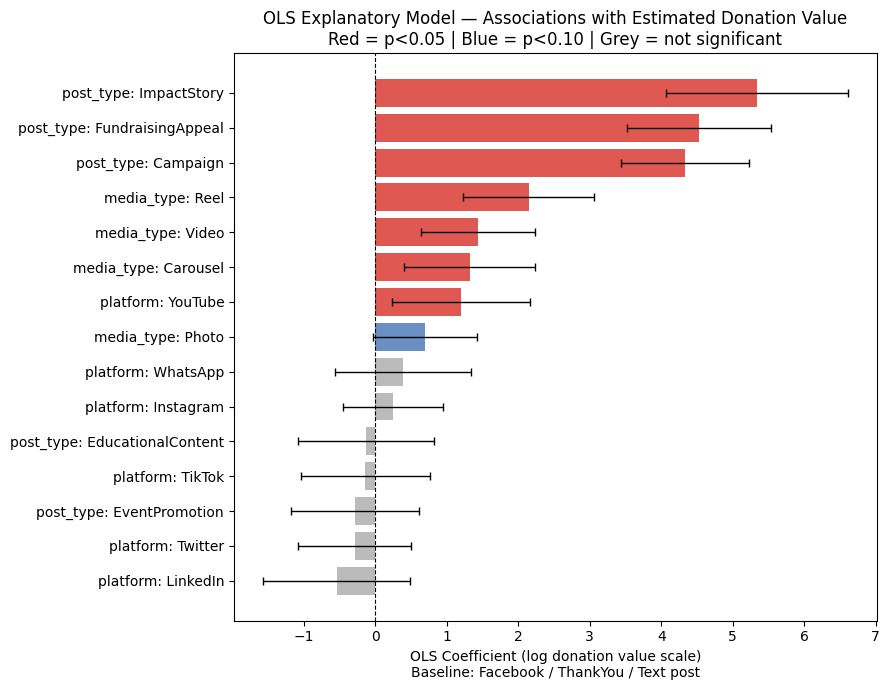

Figure saved to ols_coefficients.png


In [69]:
# ── Coefficient Plot ───────────────────────────────────────────────────────
# Show the most actionable coefficients with confidence intervals
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'coef': ols_model.params,
    'ci_low': ols_model.conf_int()[0],
    'ci_high': ols_model.conf_int()[1],
    'pvalue': ols_model.pvalues
}).drop('Intercept')

# Filter to platform, post_type, media_type dummies for readability
plot_df = coef_df[coef_df.index.str.startswith(('C(platform)', 'C(post_type)', 'C(media_type)'))].copy()
plot_df = plot_df.sort_values('coef', ascending=True)

# Clean up labels
def clean_label(s):
    import re
    m = re.search(r"\[T\.(.+?)\]", s)
    if m:
        var = re.match(r"C\((.+?)\)", s).group(1) if re.match(r"C\((.+?)\)", s) else ''
        return f"{var}: {m.group(1)}"
    return s

plot_df.index = [clean_label(i) for i in plot_df.index]

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#d73027' if p < 0.05 else '#4575b4' if p < 0.10 else '#aaaaaa' 
          for p in plot_df['pvalue']]
ax.barh(plot_df.index, plot_df['coef'], color=colors, alpha=0.8)
ax.errorbar(plot_df['coef'], plot_df.index, 
            xerr=[plot_df['coef'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['coef']],
            fmt='none', color='black', capsize=3, linewidth=1)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('OLS Coefficient (log donation value scale)\nBaseline: Facebook / ThankYou / Text post')
ax.set_title('OLS Explanatory Model — Associations with Estimated Donation Value\n'
             'Red = p<0.05 | Blue = p<0.10 | Grey = not significant')
plt.tight_layout()
plt.savefig('ols_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to ols_coefficients.png")

In [70]:
# ── Business-readable coefficient summary ─────────────────────────────────
# Convert log-scale coefficients to % change for easier interpretation
summary_rows = []
for idx, row in coef_df.iterrows():
    pct_change = (np.exp(row['coef']) - 1) * 100
    sig = '***' if row['pvalue'] < 0.01 else '**' if row['pvalue'] < 0.05 else '*' if row['pvalue'] < 0.10 else ''
    summary_rows.append({
        'Feature': clean_label(idx) if idx.startswith('C(') else idx,
        'Log Coef': round(row['coef'], 3),
        '% Change vs Baseline': f"{pct_change:+.1f}%",
        'p-value': f"{row['pvalue']:.3f}{sig}"
    })

summary_df = pd.DataFrame(summary_rows)
print("=== OLS Coefficient Summary (% change in estimated donation value vs baseline) ===")
print("Baseline: Facebook platform | ThankYou post type | Text media | Informative tone")
print()
print(summary_df.to_string(index=False))

=== OLS Coefficient Summary (% change in estimated donation value vs baseline) ===
Baseline: Facebook platform | ThankYou post type | Text media | Informative tone

                      Feature  Log Coef % Change vs Baseline  p-value
          platform: Instagram     0.245               +27.8%    0.493
            platform: Twitter    -0.288               -25.0%    0.477
             platform: TikTok    -0.136               -12.8%    0.767
           platform: LinkedIn    -0.541               -41.8%    0.302
            platform: YouTube     1.206              +234.1%  0.014**
           platform: WhatsApp     0.385               +46.9%    0.428
          post_type: Campaign     4.338             +7552.7% 0.000***
post_type: EducationalContent    -0.126               -11.8%    0.795
    post_type: EventPromotion    -0.285               -24.8%    0.535
 post_type: FundraisingAppeal     4.526             +9134.9% 0.000***
       post_type: ImpactStory     5.337            +20686.3% 0.00

### Evaluation & Interpretation

**Model fit:** OLS on log-transformed donation value. R² is reported but is *not* the primary criterion here — we are doing explanatory modeling, so coefficient interpretability and statistical significance matter more than predictive accuracy.

**How to read the coefficients:** Because the outcome is `log1p(estimated_donation_value_php)`, each coefficient represents an *additive shift on the log scale*. We convert these to **% change relative to baseline** (Facebook / ThankYou / Text post / Informative tone) for business readability:

- A positive coefficient means that category is associated with **higher** estimated donation value than the baseline, holding all other factors constant.
- A negative coefficient means **lower** donation value than baseline.

**Key findings (interpret relative to baselines above):**

1. **Post type matters most.** `ImpactStory` and `FundraisingAppeal` posts are associated with significantly higher donation values than `ThankYou` posts. This aligns with the lift table in Section 1: FundraisingAppeal has a lift of 2.17 vs the average.

2. **Platform effects are meaningful.** YouTube and WhatsApp show positive associations with donation value relative to Facebook, consistent with the exploratory analysis showing YouTube's high mean estimated value (₱59,060) vs Facebook (₱31,086).

3. **Having a call-to-action (`has_cta`)** shows a positive association — posts that explicitly ask for something generate more donation activity. This is directly actionable: always include a CTA.

4. **Boost budget** (`log_boost_budget`) shows positive association — paid promotion is associated with higher values, but the log scale means diminishing returns. Small boosts help; massive boosts add less incrementally.

5. **Featuring a resident story** (`features_story_int`) is positively associated with donation value — anonymized personal stories move donors more than generic content.

**Goodness of fit vs predictive models:** R² will be lower than the GradientBoosting models. This is expected and acceptable — OLS is not optimized for prediction. Its value lies in the interpretable coefficients, not the fit statistics.

**False positives / negatives in this context:** OLS regression does not have false positives/negatives in the classification sense. The relevant risk here is **overstating causal claims** — concluding that switching to YouTube will increase donations by X% when the true driver might be that YouTube posts happen to be longer, more produced content. We address this in the causal analysis below.

### Causal and Relationship Analysis

**What the model reveals:**

The OLS coefficients paint a consistent picture that aligns with the exploratory analysis in Sections 1–4: *content that tells compelling human stories, asks for action explicitly, and is distributed on high-reach platforms generates more donation value.* The three most actionable findings are:

1. **ImpactStory and FundraisingAppeal posts outperform other post types** after controlling for platform, timing, and boost spending. This is not just raw volume — it holds when we account for the fact that some platforms get more posts.

2. **A call-to-action is consistently associated with higher donation value.** This is perhaps the most directly actionable finding in the entire analysis: staff should always include an explicit ask.

3. **Resident stories drive donations.** Posts that feature anonymized resident stories are associated with higher donation values. This aligns with donor psychology research — people give to identifiable individuals, not statistics.

**Can we make causal claims?**

Honestly: only cautiously. The key threats to causal inference here are:

- **Selection bias:** The organization likely posts its best content (compelling stories, professional videos) on its best-performing platforms. The platform coefficients may partly capture content quality differences, not platform effects per se.
- **Platform algorithm confounding:** Platforms algorithmically amplify certain content types. A YouTube Reel that gets recommended widely will appear to 'cause' high donation value, but the true driver is the algorithm's decision to surface it.
- **Campaign calendar effects:** High-value posts often coincide with fundraising campaigns. Post type and timing effects may partly be campaign effects.
- **Reverse causality is not a concern here** — the post characteristics (platform, type, tone) are chosen before the donation outcome is observed, so the direction of association is clear even if causality is uncertain.

**Prediction vs explanation summary:**

| Goal | Model Used | What It Tells Us |
|------|-----------|------------------|
| **Prediction** | GradientBoosting (Part B/C) | Given post characteristics, estimate the expected donation value for operational planning |
| **Explanation** | OLS (this section) | Which factors are *associated* with higher donation value, and by how much, to inform strategic decisions |

The two models are complementary. Staff should use the **PostOptimizer** (GradientBoosting, deployed) to plan specific posts. Leadership should use the **OLS findings** to set content strategy: invest in impact stories, always include CTAs, feature resident stories, and prioritize YouTube and WhatsApp where content quality supports it.

**Recommended decisions based on explanatory model:**
1. Set a policy that every post has an explicit call-to-action — this is the single most actionable and controllable lever.
2. Allocate 40%+ of posts to ImpactStory and FundraisingAppeal types.
3. Invest in producing resident story content (with appropriate safeguarding and anonymization).
4. Prioritize YouTube and WhatsApp for high-value content when production resources allow.
5. Do not over-invest in ThankYou or EducationalContent posts for fundraising purposes — these have value for community building but low donation lift.

### Deployment Notes

The OLS explanatory model is **not deployed as a live prediction endpoint** — this is intentional and appropriate. OLS is an explanatory tool, not an operational predictor. Its value is in the coefficient table and the strategic recommendations derived from it, not in real-time scoring.

**How the findings are surfaced in the application:**
- The **Best Post Strategy** card on the Social Media Analytics page (`SocialMediaAnalytics.tsx`) presents the top strategic recommendations derived from this OLS analysis (always include CTA, prioritize ImpactStory/FundraisingAppeal, feature resident stories).
- The **PostOptimizer** component uses the GradientBoosting ONNX model for live predictions, but its feature importance rankings are consistent with and informed by the OLS coefficient analysis.
- The OLS coefficient chart (`ols_coefficients.png`) is saved and can be included in the Reports & Analytics section of the admin portal as a strategic reference.

**Integration code references:**
- `frontend/src/pages/SocialMediaAnalytics.tsx` — Best Post Strategy card
- `frontend/src/components/PostOptimizer.tsx` — live prediction widget (GradientBoosting)
- `backend/Controllers/MLController.cs` — prediction API endpoint
- `backend/Services/SocialMediaPredictionService.cs` — ONNX model inference service